# Exploratory Data Analysis

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

### Load the Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_hotel_bookings.csv")

## Booking Analysis

In [3]:
monthly_bookings = (

    df.groupby("arrival_date_month")

    .size()

    .reset_index(name="Bookings")

)

monthly_bookings

,arrival_date_month,Bookings
0,April,7900
1,August,11238
2,December,5112
3,February,6083
4,January,4685
5,July,10043
6,June,7756
7,March,7488
8,May,8344
9,November,4973


### Since month names are not automatically in calendar order, reorder them.

In [4]:
month_order = [

    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"

]

monthly_bookings["arrival_date_month"] = pd.Categorical(

    monthly_bookings["arrival_date_month"],

    categories=month_order,

    ordered=True

)

monthly_bookings = monthly_bookings.sort_values(
    "arrival_date_month"
)

### Plot the monthly booking trend.

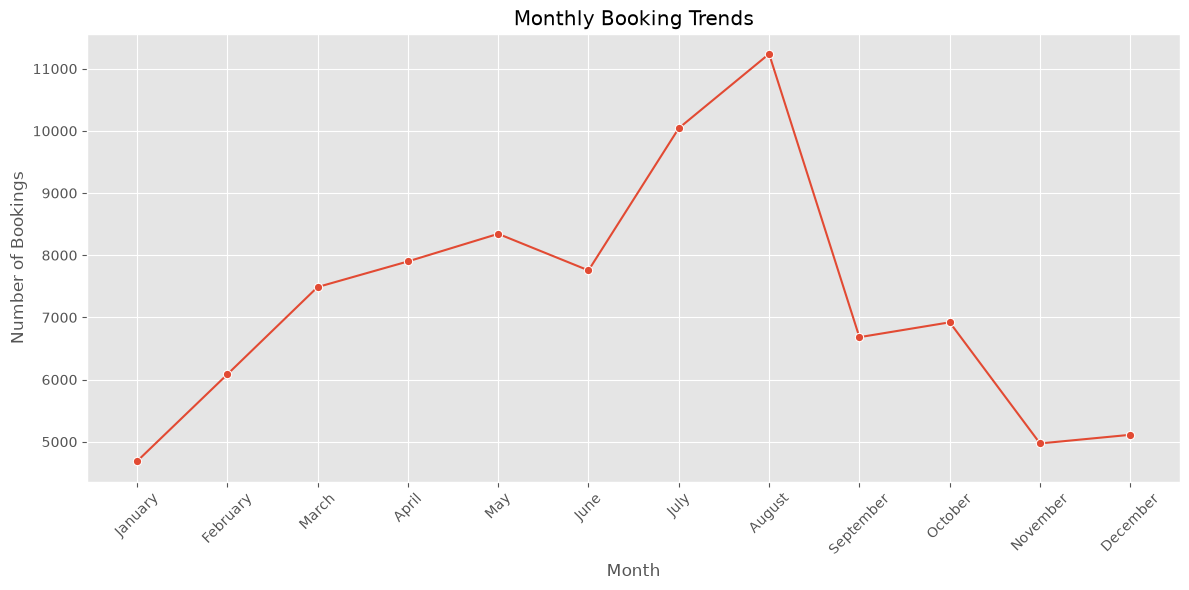

In [5]:
plt.figure(figsize=(12,6))

sns.lineplot(

    data=monthly_bookings,

    x="arrival_date_month",

    y="Bookings",

    marker="o"

)

plt.xticks(rotation=45)

plt.title("Monthly Booking Trends")

plt.xlabel("Month")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/monthly_booking_trend.png",

    dpi=300

)

plt.show()

In [6]:
monthly_bookings

,arrival_date_month,Bookings
4,January,4685
3,February,6083
7,March,7488
0,April,7900
8,May,8344
6,June,7756
5,July,10043
1,August,11238
11,September,6682
10,October,6921


## Business Interpretation

#### The monthly booking trend illustrates seasonal demand patterns throughout the year. Identifying peak and off-peak months enables hotel managers to optimize staffing, promotional campaigns, pricing strategies, and resource allocation to maximize occupancy and revenue.

## Conclusion

#### Monthly booking analysis reveals seasonal fluctuations in hotel demand. These trends provide valuable insights for forecasting future bookings and planning operational resources during both high-demand and low-demand periods.

# Hotel Type Comparison

### Booking Count by Hotel Type

In [7]:
hotel_booking_count = (

    df.groupby("hotel")

    .size()

    .reset_index(name="Bookings")

)

hotel_booking_count

,hotel,Bookings
0,City Hotel,53270
1,Resort Hotel,33955


### Calculate Percentage Share

In [8]:
hotel_booking_count["Percentage"] = (

    hotel_booking_count["Bookings"]

    / hotel_booking_count["Bookings"].sum()

) * 100

hotel_booking_count["Percentage"] = (

    hotel_booking_count["Percentage"]

    .round(2)

)

hotel_booking_count

,hotel,Bookings,Percentage
0,City Hotel,53270,61.07
1,Resort Hotel,33955,38.93


### Bar Chart

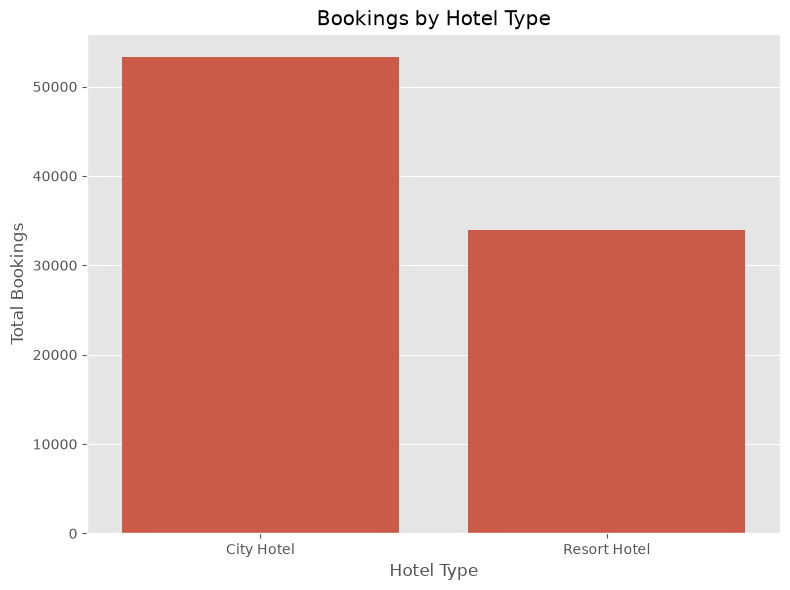

In [9]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=hotel_booking_count,

    x="hotel",

    y="Bookings"

)

plt.title("Bookings by Hotel Type")

plt.xlabel("Hotel Type")

plt.ylabel("Total Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/hotel_type_bookings_bar.png",

    dpi=300

)

plt.show()


### Pie Chart

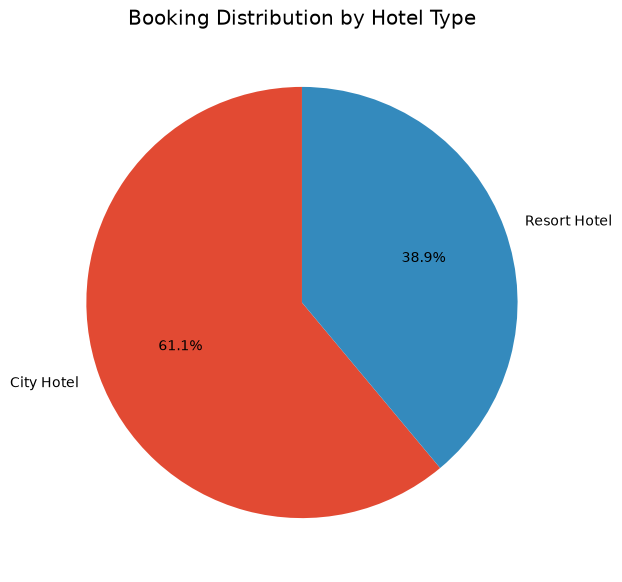

In [10]:
plt.figure(figsize=(7,7))

plt.pie(

    hotel_booking_count["Bookings"],

    labels=hotel_booking_count["hotel"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Booking Distribution by Hotel Type")

plt.savefig(

    "../figures/phase_06/hotel_type_bookings_pie.png",

    dpi=300

)

plt.show()

In [11]:
hotel_booking_count

,hotel,Bookings,Percentage
0,City Hotel,53270,61.07
1,Resort Hotel,33955,38.93


## Business Interpretation

#### Comparing booking volumes between City Hotels and Resort Hotels helps identify customer preferences. If one hotel type consistently attracts a larger share of bookings, hotel management can investigate the underlying factors, such as location, pricing, amenities, or seasonal demand, to improve occupancy and marketing strategies.

## Conclusion

#### Hotel type comparison revealed the distribution of bookings between City Hotels and Resort Hotels. The analysis highlights customer preferences and provides insights that support operational planning, investment decisions, and targeted marketing initiatives.

# Booking Lead Time Analysis

### Descriptive Statistics

In [12]:
lead_time_summary = df["lead_time"].describe()

lead_time_summary

count    87225.000000
mean        78.444918
std         81.052481
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        296.000000
Name: lead_time, dtype: float64

### Additional Statistics

In [13]:
lead_time_stats = pd.DataFrame({

    "Statistic": [

        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"

    ],

    "Value": [

        df["lead_time"].min(),

        df["lead_time"].max(),

        round(df["lead_time"].mean(), 2),

        df["lead_time"].median(),

        round(df["lead_time"].std(), 2)

    ]

})

lead_time_stats

,Statistic,Value
0,Minimum,0.00
1,Maximum,296.00
2,Mean,78.44
3,Median,49.00
4,Standard Deviation,81.05


### Histogram

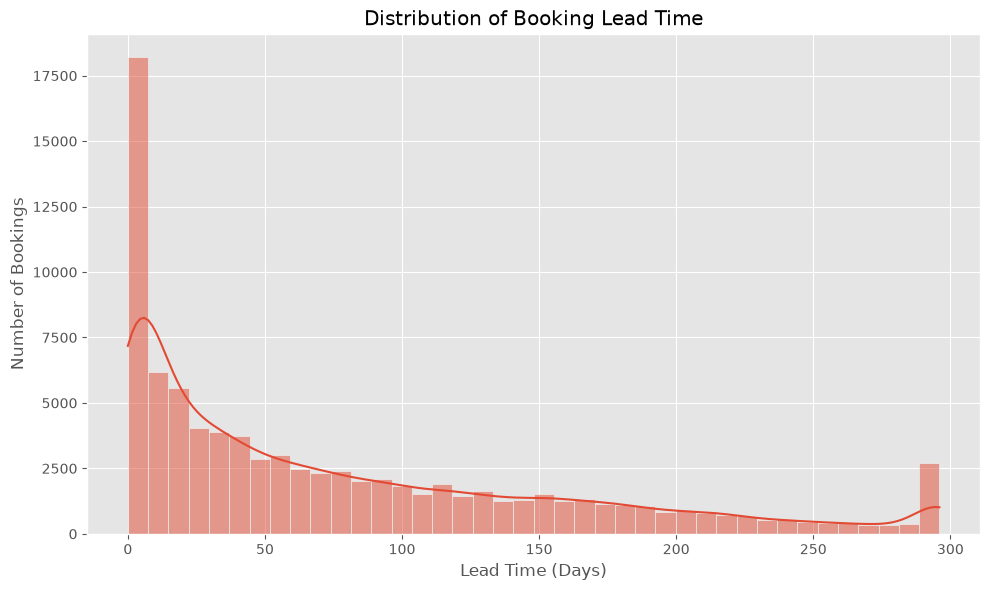

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(

    data=df,

    x="lead_time",

    bins=40,

    kde=True

)

plt.title("Distribution of Booking Lead Time")

plt.xlabel("Lead Time (Days)")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/lead_time_histogram.png",

    dpi=300

)

plt.show()

### Box Plot

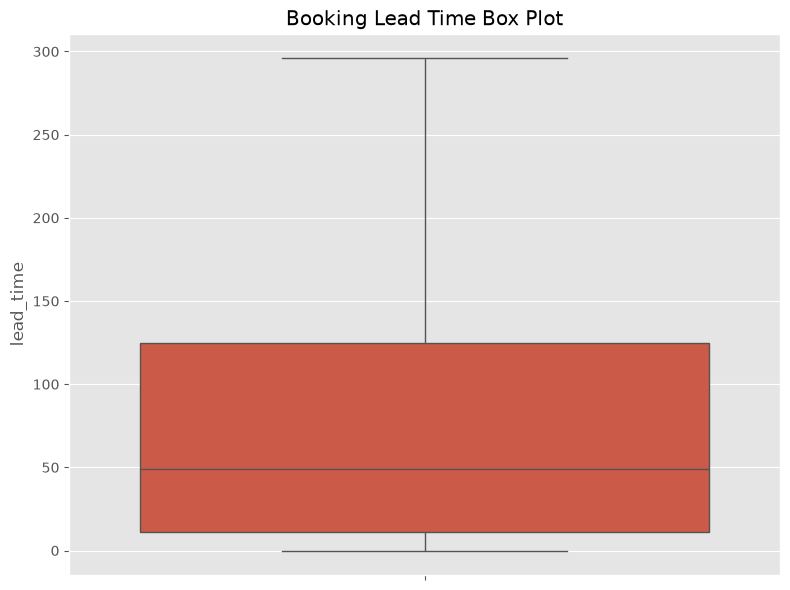

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(

    y=df["lead_time"]

)

plt.title("Booking Lead Time Box Plot")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/lead_time_boxplot.png",

    dpi=300

)

plt.show()

### Booking Lead Time Categories

In [16]:
bins = [-1, 7, 30, 90, 180, df["lead_time"].max()]

labels = [

    "0-7 Days",

    "8-30 Days",

    "31-90 Days",

    "91-180 Days",

    "180+ Days"

]

df["lead_time_category"] = pd.cut(

    df["lead_time"],

    bins=bins,

    labels=labels

)

### Category Summary

In [17]:
lead_time_category = (

    df["lead_time_category"]

    .value_counts()

    .sort_index()

    .reset_index()

)

lead_time_category.columns = [

    "Lead Time Category",

    "Bookings"

]

lead_time_category

,Lead Time Category,Bookings
0,0-7 Days,18200
1,8-30 Days,16325
2,31-90 Days,22720
3,91-180 Days,18224
4,180+ Days,11756


### Lead Time Category Bar Chart

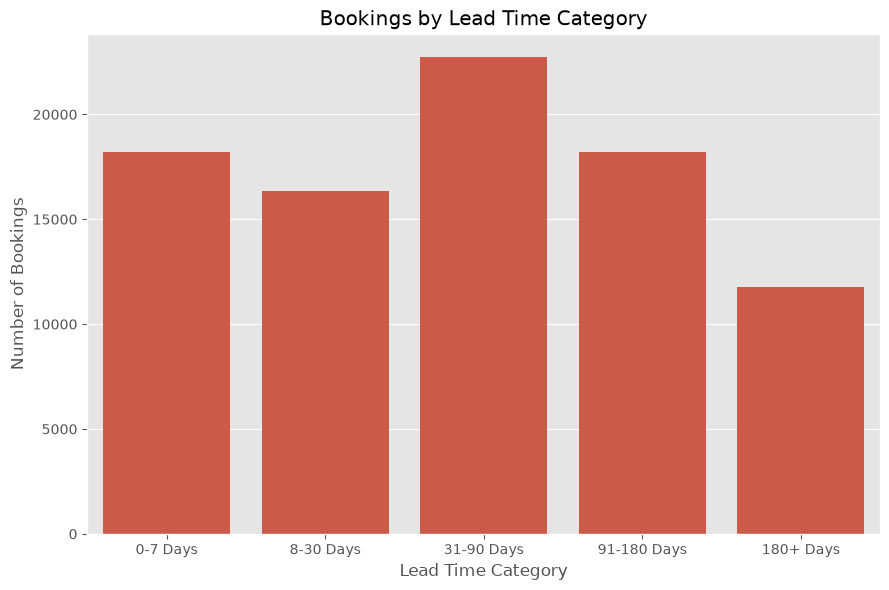

In [18]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=lead_time_category,

    x="Lead Time Category",

    y="Bookings"

)

plt.title("Bookings by Lead Time Category")

plt.xlabel("Lead Time Category")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/lead_time_category_bar.png",

    dpi=300

)

plt.show()

In [19]:
lead_time_category

,Lead Time Category,Bookings
0,0-7 Days,18200
1,8-30 Days,16325
2,31-90 Days,22720
3,91-180 Days,18224
4,180+ Days,11756


## Business Interpretation

#### Lead time analysis provides insights into customer booking behavior by showing how far in advance reservations are made. Hotels can use this information to optimize pricing strategies, forecast demand, launch early booking promotions, and manage room availability more effectively. Understanding booking windows also supports better staffing and operational planning.

## Conclusion

#### Booking lead time analysis revealed the distribution of reservation timing across different booking windows. The histogram, box plot, and categorized booking ranges provide a comprehensive understanding of customer booking patterns, enabling data-driven pricing and demand management decisions.

# Seasonal Booking Trends

### Create Season Feature

In [20]:
season_mapping = {

    "December": "Winter",
    "January": "Winter",
    "February": "Winter",

    "March": "Spring",
    "April": "Spring",
    "May": "Spring",

    "June": "Summer",
    "July": "Summer",
    "August": "Summer",

    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn"

}

df["season"] = df["arrival_date_month"].map(
    season_mapping
)

### Seasonal Booking Summary

In [21]:
seasonal_bookings = (

    df.groupby("season")

    .size()

    .reset_index(name="Bookings")

)

season_order = [

    "Spring",
    "Summer",
    "Autumn",
    "Winter"

]

seasonal_bookings["season"] = pd.Categorical(

    seasonal_bookings["season"],

    categories=season_order,

    ordered=True

)

seasonal_bookings = seasonal_bookings.sort_values(
    "season"
)

seasonal_bookings

,season,Bookings
1,Spring,23732
2,Summer,29037
0,Autumn,18576
3,Winter,15880


### Calculate Percentage

In [22]:
seasonal_bookings["Percentage"] = (

    seasonal_bookings["Bookings"]

    / seasonal_bookings["Bookings"].sum()

) * 100

seasonal_bookings["Percentage"] = (

    seasonal_bookings["Percentage"]

    .round(2)

)

seasonal_bookings

,season,Bookings,Percentage
1,Spring,23732,27.21
2,Summer,29037,33.29
0,Autumn,18576,21.30
3,Winter,15880,18.21


### Bar Chart

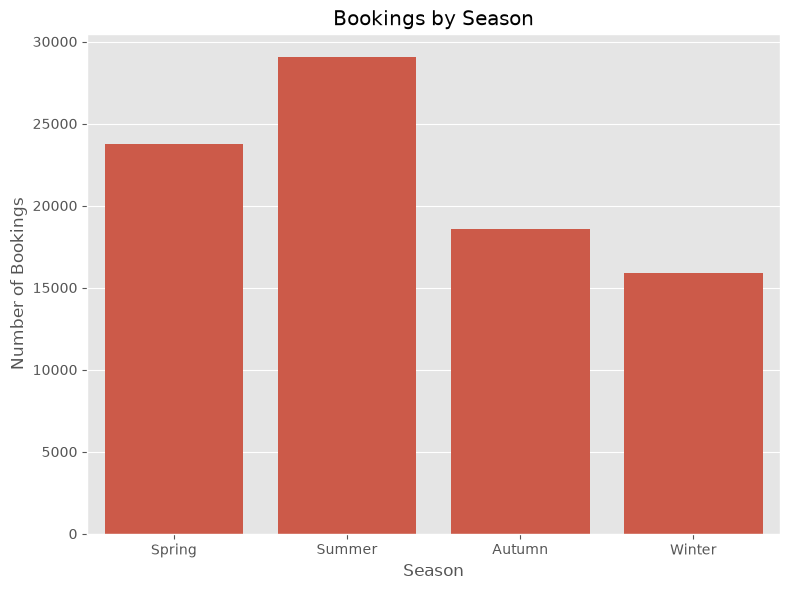

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(

    data=seasonal_bookings,

    x="season",

    y="Bookings"

)

plt.title("Bookings by Season")

plt.xlabel("Season")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/seasonal_bookings_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

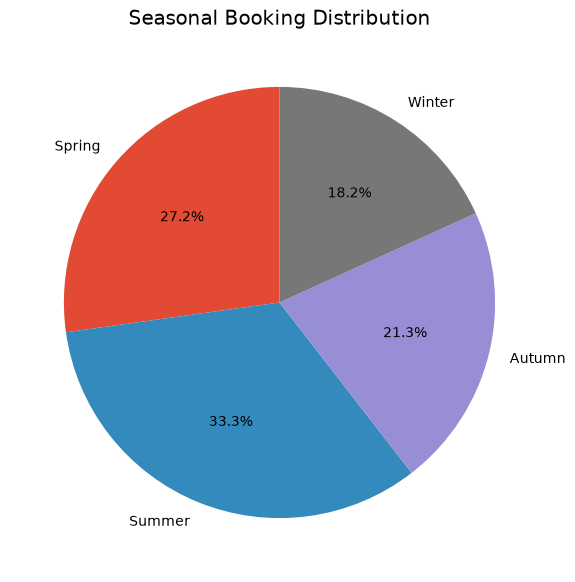

In [24]:
plt.figure(figsize=(7,7))

plt.pie(

    seasonal_bookings["Bookings"],

    labels=seasonal_bookings["season"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Seasonal Booking Distribution")

plt.savefig(

    "../figures/phase_06/seasonal_bookings_pie.png",

    dpi=300

)

plt.show()

### Hotel Type vs Season

In [25]:
hotel_season = pd.crosstab(

    df["season"],

    df["hotel"]

)

hotel_season

hotel,City Hotel,Resort Hotel
season,,
Autumn,11351,7225
Spring,15307,8425
Summer,17299,11738
Winter,9313,6567


### Stacked Bar Chart

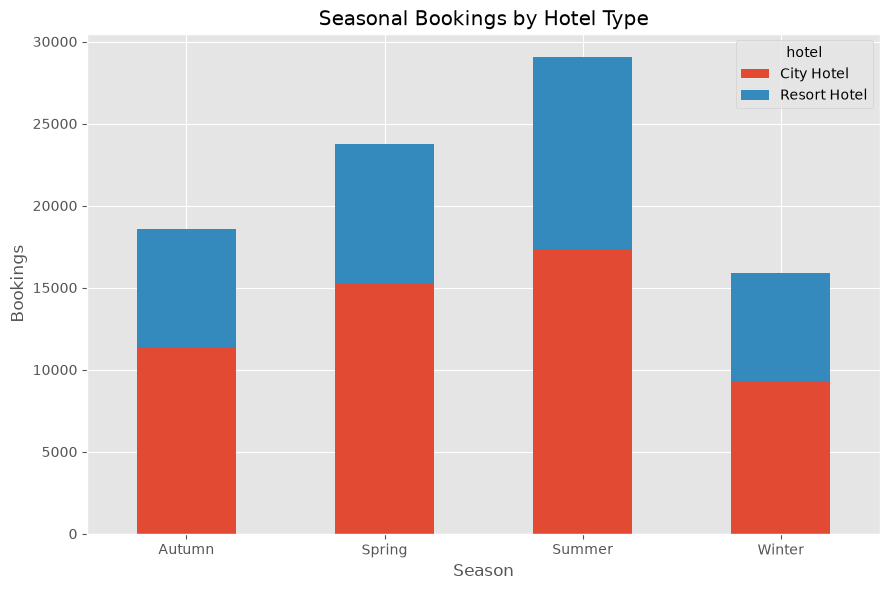

In [26]:
hotel_season.plot(

    kind="bar",

    stacked=True,

    figsize=(9,6)

)

plt.title("Seasonal Bookings by Hotel Type")

plt.xlabel("Season")

plt.ylabel("Bookings")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/season_hoteltype_stacked.png",

    dpi=300

)

plt.show()

In [27]:
seasonal_bookings

,season,Bookings,Percentage
1,Spring,23732,27.21
2,Summer,29037,33.29
0,Autumn,18576,21.30
3,Winter,15880,18.21


## Business Interpretation

#### Seasonal booking analysis identifies peak and off-peak demand periods throughout the year. Understanding seasonal booking behavior enables hotel management to optimize pricing strategies, staffing levels, inventory planning, promotional campaigns, and resource allocation. Comparing hotel types across seasons also provides insights into customer preferences during different times of the year.

## Conclusion

#### Seasonal booking trend analysis revealed how hotel demand varies throughout the year. The bar chart, pie chart, and hotel-type comparison highlight seasonal booking patterns and customer preferences, providing valuable information for strategic planning and revenue optimization.

# Customer Type Distribution

In [28]:
# summary

customer_type_summary = (

    df.groupby("customer_type")

    .size()

    .reset_index(name="Bookings")

)

customer_type_summary

,customer_type,Bookings
0,Contract,3135
1,Group,541
2,Transient,71862
3,Transient-Party,11687


### Calculate Percentage

In [29]:
customer_type_summary["Percentage"] = (

    customer_type_summary["Bookings"]

    / customer_type_summary["Bookings"].sum()

) * 100

customer_type_summary["Percentage"] = (

    customer_type_summary["Percentage"]

    .round(2)

)

customer_type_summary

,customer_type,Bookings,Percentage
0,Contract,3135,3.59
1,Group,541,0.62
2,Transient,71862,82.39
3,Transient-Party,11687,13.40


### Sort by Bookings

In [30]:
customer_type_summary = customer_type_summary.sort_values(

    by="Bookings",

    ascending=False

)

customer_type_summary

,customer_type,Bookings,Percentage
2,Transient,71862,82.39
3,Transient-Party,11687,13.40
0,Contract,3135,3.59
1,Group,541,0.62


### Bar Chart

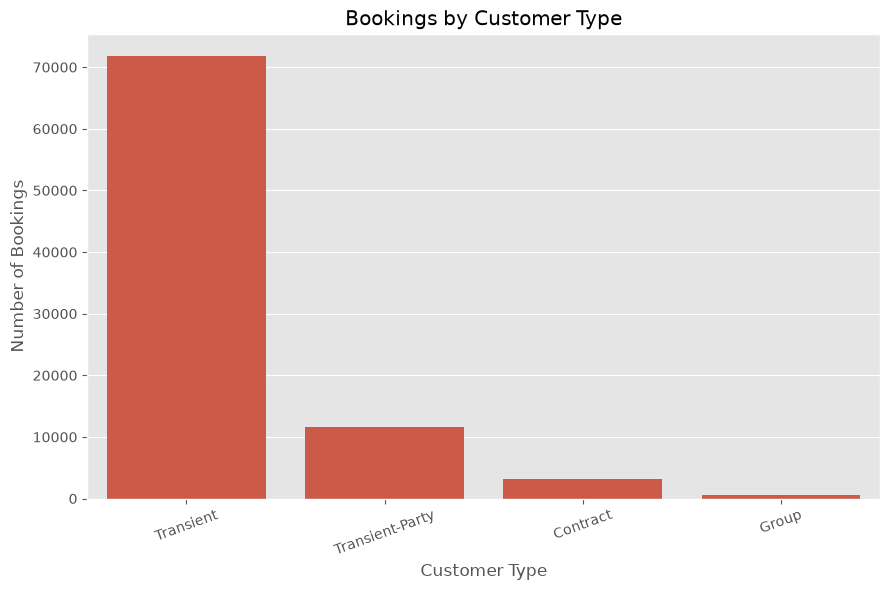

In [31]:
plt.figure(figsize=(9,6))

sns.barplot(

    data=customer_type_summary,

    x="customer_type",

    y="Bookings"

)

plt.title("Bookings by Customer Type")

plt.xlabel("Customer Type")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/customer_type_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

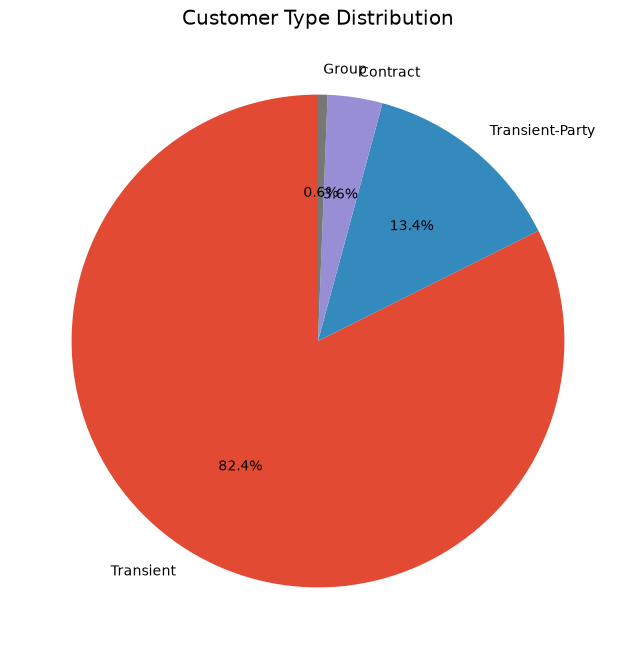

In [32]:
plt.figure(figsize=(8,8))

plt.pie(

    customer_type_summary["Bookings"],

    labels=customer_type_summary["customer_type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Customer Type Distribution")

plt.savefig(

    "../figures/phase_06/customer_type_pie.png",

    dpi=300

)

plt.show()

In [33]:
customer_type_summary

,customer_type,Bookings,Percentage
2,Transient,71862,82.39
3,Transient-Party,11687,13.40
0,Contract,3135,3.59
1,Group,541,0.62


### Identify the Largest Customer Segment

In [34]:
top_customer = customer_type_summary.iloc[0]

print("Top Customer Type :", top_customer["customer_type"])

print("Bookings :", top_customer["Bookings"])

print("Percentage :", top_customer["Percentage"], "%")

Top Customer Type : Transient
Bookings : 71862
Percentage : 82.39 %


## Business Interpretation

#### Customer type distribution provides insight into the composition of the hotel's customer base. A high proportion of transient customers may indicate dependence on individual travelers, while a larger share of contract or group customers suggests stronger corporate partnerships or organized travel demand. These insights help hotels tailor marketing campaigns, pricing strategies, and loyalty programs for different customer segments.

## Conclusion

#### Customer type analysis revealed the distribution of bookings across different customer categories. The results identify the dominant customer segment and provide valuable information for customer relationship management, marketing strategies, and business planning.

# Country-wise Bookings

### Country-wise Booking Summary

In [35]:
country_bookings = (

    df.groupby("country")

    .size()

    .reset_index(name="Bookings")

)

country_bookings = country_bookings.sort_values(

    by="Bookings",

    ascending=False

)

country_bookings.head(10)

,country,Bookings
135,PRT,27351
59,GBR,10423
56,FRA,8823
51,ESP,7244
43,DEU,5385
81,ITA,3061
76,IRL,3015
15,BEL,2081
25,BRA,1993
123,NLD,1910


### Top 10 Countries

In [36]:
top10_countries = country_bookings.head(10)

top10_countries

,country,Bookings
135,PRT,27351
59,GBR,10423
56,FRA,8823
51,ESP,7244
43,DEU,5385
81,ITA,3061
76,IRL,3015
15,BEL,2081
25,BRA,1993
123,NLD,1910


### Percentage Contribution

In [37]:
top10_countries["Percentage"] = (

    top10_countries["Bookings"]

    / df.shape[0]

) * 100

top10_countries["Percentage"] = (

    top10_countries["Percentage"]

    .round(2)

)

top10_countries

,country,Bookings,Percentage
135,PRT,27351,31.36
59,GBR,10423,11.95
56,FRA,8823,10.12
51,ESP,7244,8.30
43,DEU,5385,6.17
81,ITA,3061,3.51
76,IRL,3015,3.46
15,BEL,2081,2.39
25,BRA,1993,2.28
123,NLD,1910,2.19


### Horizontal Bar Chart

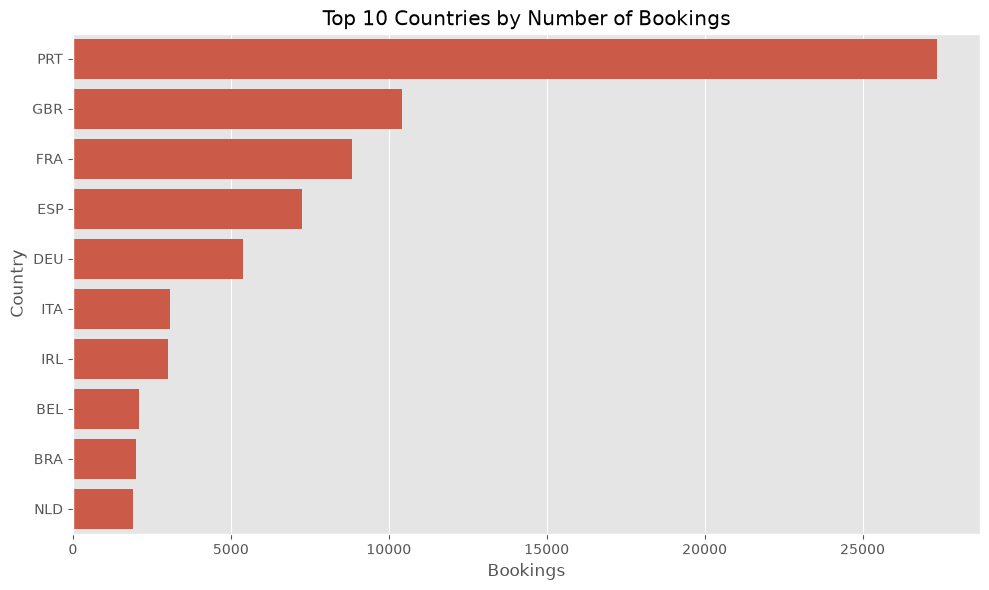

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=top10_countries,

    y="country",

    x="Bookings"

)

plt.title("Top 10 Countries by Number of Bookings")

plt.xlabel("Bookings")

plt.ylabel("Country")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/top10_country_bookings_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

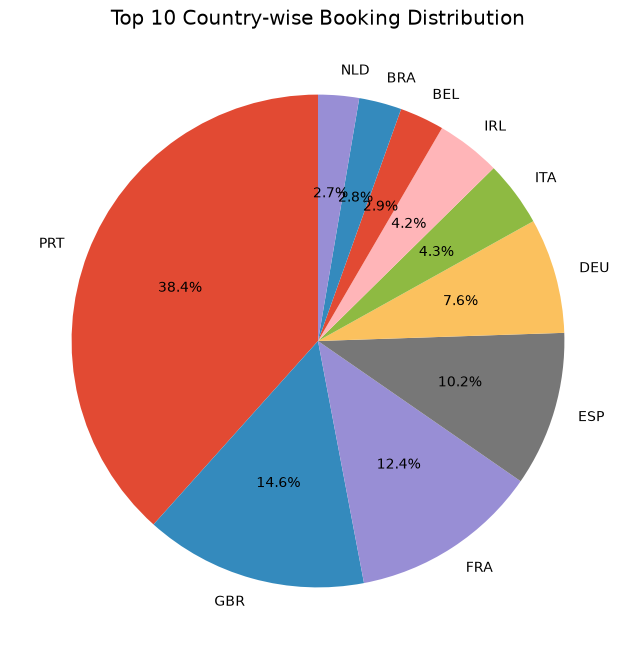

In [39]:
plt.figure(figsize=(8,8))

plt.pie(

    top10_countries["Bookings"],

    labels=top10_countries["country"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Top 10 Country-wise Booking Distribution")

plt.savefig(

    "../figures/phase_06/top10_country_bookings_pie.png",

    dpi=300

)

plt.show()

In [40]:
top10_countries

,country,Bookings,Percentage
135,PRT,27351,31.36
59,GBR,10423,11.95
56,FRA,8823,10.12
51,ESP,7244,8.30
43,DEU,5385,6.17
81,ITA,3061,3.51
76,IRL,3015,3.46
15,BEL,2081,2.39
25,BRA,1993,2.28
123,NLD,1910,2.19


### Top Booking Country

In [41]:
top_country = top10_countries.iloc[0]

print("Top Country :", top_country["country"])

print("Bookings :", top_country["Bookings"])

print("Percentage :", top_country["Percentage"], "%")

Top Country : PRT
Bookings : 27351
Percentage : 31.36 %


## Business Interpretation

#### Country-wise booking analysis identifies the major geographic markets contributing to hotel reservations. Recognizing the top booking countries helps hotel management develop targeted marketing campaigns, improve multilingual customer support, establish partnerships with travel agencies, and optimize pricing strategies for high-demand regions.

## Conclusion

#### Country-wise booking analysis highlighted the top international markets contributing to hotel reservations. The results provide valuable insights into customer demographics and support strategic decisions related to marketing, customer service, and business expansion.

# Repeat Guest Analysis

### Create Guest Category

In [42]:
df["guest_type"] = df["is_repeated_guest"].map({

    0: "First-Time Guest",

    1: "Repeat Guest"

})

### Guest Type Summary

In [43]:
repeat_guest_summary = (

    df.groupby("guest_type")

    .size()

    .reset_index(name="Bookings")

)

repeat_guest_summary

,guest_type,Bookings


### Calculate Percentage

In [44]:
repeat_guest_summary["Percentage"] = (

    repeat_guest_summary["Bookings"]

    / repeat_guest_summary["Bookings"].sum()

) * 100

repeat_guest_summary["Percentage"] = (

    repeat_guest_summary["Percentage"]

    .round(2)

)

repeat_guest_summary

,guest_type,Bookings,Percentage


### Bar Chart

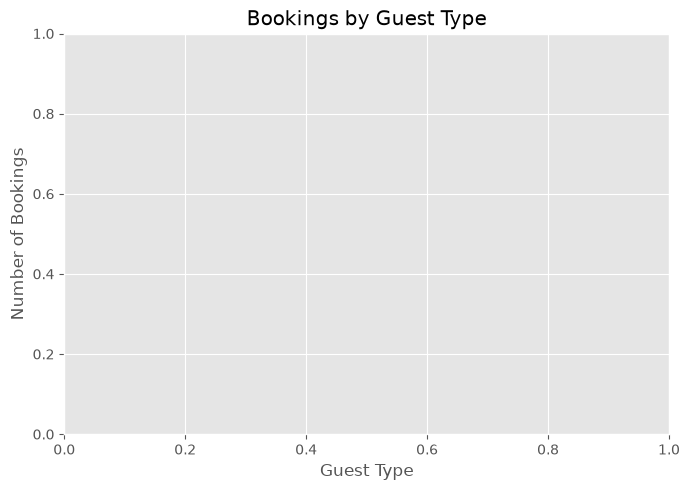

In [45]:
plt.figure(figsize=(7,5))

sns.barplot(

    data=repeat_guest_summary,

    x="guest_type",

    y="Bookings"

)

plt.title("Bookings by Guest Type")

plt.xlabel("Guest Type")

plt.ylabel("Number of Bookings")

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/repeat_guest_bar.png",

    dpi=300

)

plt.show()

### Pie Chart

ValueError: All wedge sizes are zero

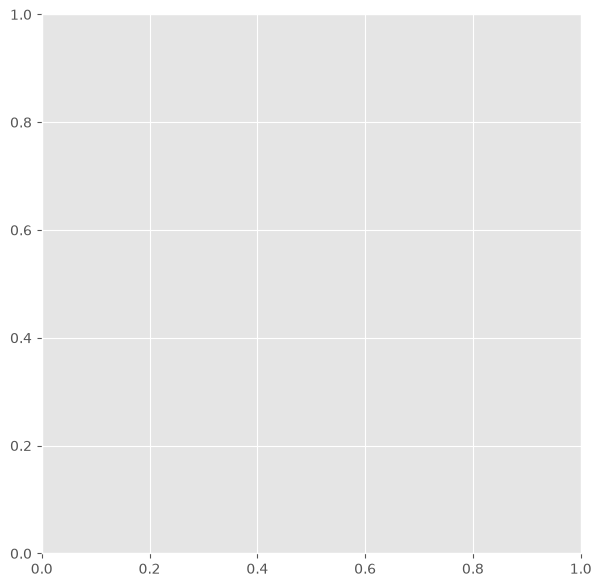

In [47]:
plt.figure(figsize=(7,7))

plt.pie(

    repeat_guest_summary["Bookings"],

    labels=repeat_guest_summary["guest_type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Repeat Guest Distribution")

plt.savefig(

    "../figures/phase_06/repeat_guest_pie.png",

    dpi=300

)

plt.show()

### Cancellation Rate by Guest Type

In [48]:
guest_cancellation = pd.crosstab(

    df["guest_type"],

    df["is_canceled"],

    normalize="index"

) * 100

guest_cancellation.round(2)

is_canceled
guest_type


### Stacked Bar Chart

TypeError: no numeric data to plot

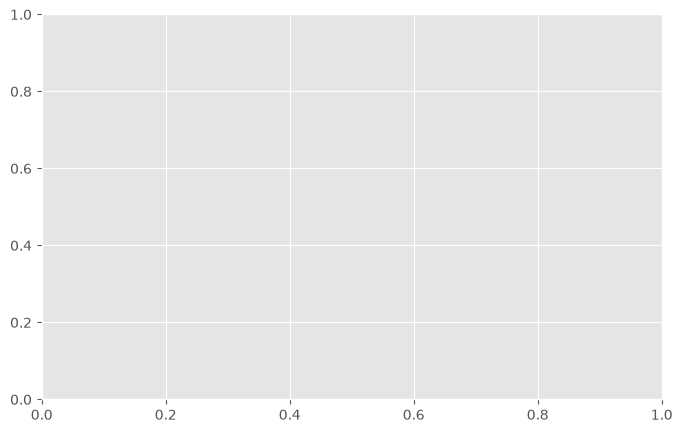

In [49]:
guest_cancellation.plot(

    kind="bar",

    stacked=True,

    figsize=(8,5)

)

plt.title("Cancellation Rate by Guest Type")

plt.xlabel("Guest Type")

plt.ylabel("Percentage")

plt.legend(

    title="Cancelled",

    labels=["Not Cancelled", "Cancelled"]

)

plt.tight_layout()

plt.savefig(

    "../figures/phase_06/repeat_guest_cancellation.png",

    dpi=300

)

plt.show()

In [50]:
repeat_guest_summary

,guest_type,Bookings,Percentage
